Requirements

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# 🔧 Setup for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

#Load Dataset
df=pd.read_csv("data/Sample.csv")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
#remove null values

df.dropna(inplace=True)

#convert Order-date to date_time

Order_Date=pd.to_datetime(df['Order Date'])

df['City']=df['City'].astype(str)+','+df['Region']

Category=df['Category']

Sales=pd.to_numeric(df['Sales'],errors='coerce')

region=df['Region']

profit=df['Profit'].astype(float)

df['Sub-Category']=df['Sub-Category'].astype(str)

month= Order_Date.dt.month


In [3]:
city_sales=df.groupby('Region').sum(numeric_only=True)['Sales']

Visualizing Monthly Sales 

Text(0, 0.5, 'Sales')

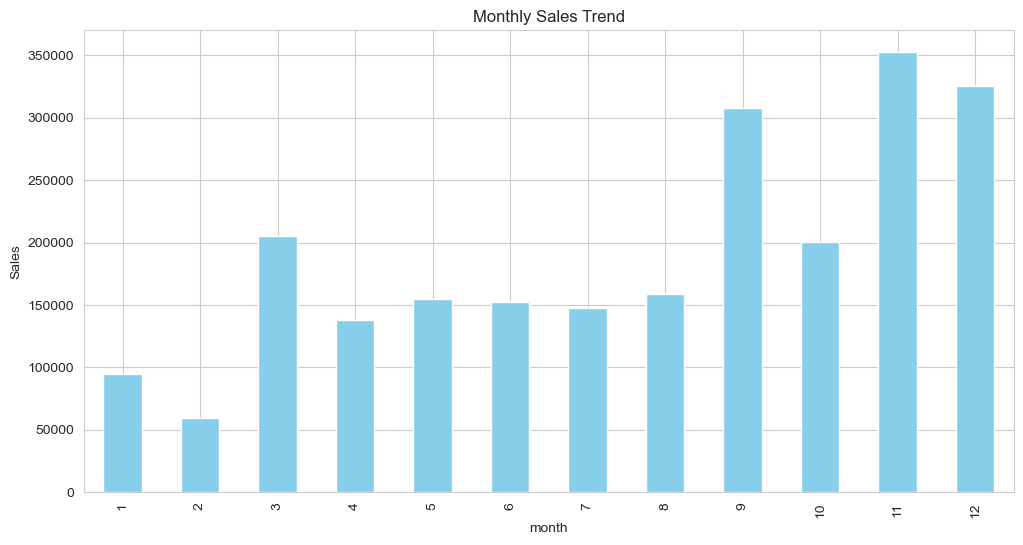

In [4]:
monthly_sales= df.groupby(month).sum(numeric_only=True)['Sales']

monthly_sales.plot(kind='bar', color='skyblue')
plt.title("Monthly Sales Trend")
plt.xlabel("month")
plt.ylabel("Sales")

Visualising City-wise Sales

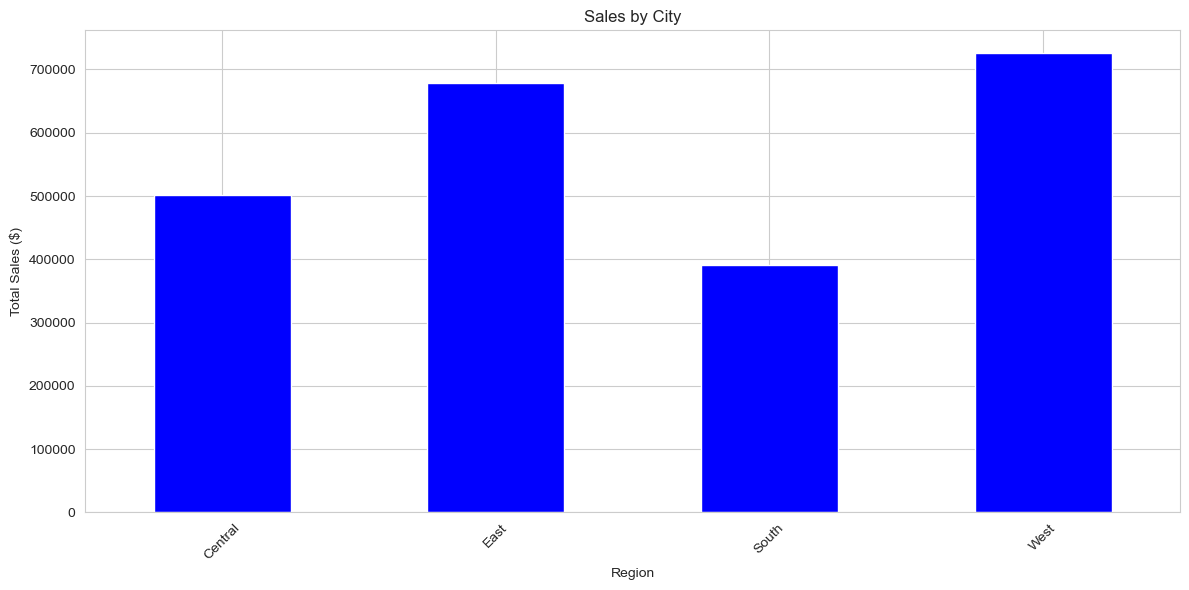

In [5]:
# Recheck groupby
city_sales = df.groupby('Region').sum()['Sales']

# Plot
city_sales.plot(kind='bar', color='blue')
plt.title('Sales by City')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
df['Customer ID']=df['Customer ID'].astype(str)
combined_sales=df.groupby('Customer ID').sum()
combined_sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Customer ID,,,,,,,,,,,,,,,,,,,,
AA-10315,43823,CA-2017-147039CA-2017-147039CA-2015-121391CA-2...,6/29/20176/29/201710/4/20153/31/20143/31/20143...,7/4/20177/4/201710/7/20154/5/20144/5/20143/8/2...,Standard ClassStandard ClassFirst ClassStandar...,Alex AvilaAlex AvilaAlex AvilaAlex AvilaAlex A...,ConsumerConsumerConsumerConsumerConsumerConsum...,United StatesUnited StatesUnited StatesUnited ...,"Minneapolis,CentralMinneapolis,CentralSan Fran...",MinnesotaMinnesotaCaliforniaCaliforniaCaliforn...,727845,CentralCentralWestWestWestCentralCentralCentra...,OFF-AP-10000576OFF-BI-10004654OFF-ST-10001590O...,Office SuppliesOffice SuppliesOffice SuppliesO...,AppliancesBindersStorageBindersAppliancesSuppl...,"Belkin 325VA UPS Surge Protector, 6'Avery Bind...",5563.560,30,1.00,-362.8825
AA-10375,60900,CA-2016-126613CA-2015-140921CA-2015-140921CA-2...,7/10/20162/3/20152/3/20154/21/20145/8/201511/1...,7/16/20162/5/20152/5/20154/25/20145/12/201511/...,Standard ClassFirst ClassFirst ClassStandard C...,Allen ArmoldAllen ArmoldAllen ArmoldAllen Armo...,ConsumerConsumerConsumerConsumerConsumerConsum...,United StatesUnited StatesUnited StatesUnited ...,"Mesa,WestOmaha,CentralOmaha,CentralLos Angeles...",ArizonaNebraskaNebraskaCaliforniaOregonGeorgia...,664413,WestCentralCentralWestWestSouthSouthSouthWestS...,OFF-ST-10001325FUR-FU-10003347TEC-AC-10004901O...,Office SuppliesFurnitureTechnologyOffice Suppl...,StorageFurnishingsAccessoriesBindersArtAccesso...,Sterilite Officeware Hinged File BoxColoredge ...,1056.390,41,1.20,277.3824
AA-10480,55548,CA-2017-114412CA-2014-155271CA-2016-121671CA-2...,4/15/20175/4/20147/17/20167/17/20167/17/20167/...,4/20/20175/4/20147/22/20167/22/20167/22/20167/...,Standard ClassSame DayStandard ClassStandard C...,Andrew AllenAndrew AllenAndrew AllenAndrew All...,ConsumerConsumerConsumerConsumerConsumerConsum...,United StatesUnited StatesUnited StatesUnited ...,"Concord,SouthMiddletown,EastSpringfield,Centra...",North CarolinaConnecticutMissouriMissouriMisso...,604689,SouthEastCentralCentralCentralCentralCentralCe...,OFF-PA-10002365FUR-FU-10001473OFF-PA-10001471O...,Office SuppliesFurnitureOffice SuppliesOffice ...,PaperFurnishingsPaperStoragePaperPaperStorageP...,Xerox 1967DAX Wood Document FrameStrathmore Ph...,1790.512,36,0.20,435.8274
AA-10645,109566,CA-2014-154963CA-2014-154963CA-2014-154963CA-2...,6/22/20146/22/20146/22/20147/4/20167/4/20167/4...,6/27/20146/27/20146/27/20147/6/20167/6/20167/6...,Standard ClassStandard ClassStandard ClassFirs...,Anna AndreadiAnna AndreadiAnna AndreadiAnna An...,ConsumerConsumerConsumerConsumerConsumerConsum...,United StatesUnited StatesUnited StatesUnited ...,"Chester,EastChester,EastChester,EastSan Franci...",PennsylvaniaPennsylvaniaPennsylvaniaCalifornia...,911792,EastEastEastWestWestWestWestSouthSouthSouthSou...,FUR-CH-10004698TEC-PH-10004093FUR-CH-10000454F...,FurnitureTechnologyFurnitureFurnitureOffice Su...,ChairsPhonesChairsFurnishingsEnvelopesBookcase...,"Padded Folding Chairs, Black, 4/CartonPanasoni...",5086.935,64,1.15,857.8033
AB-10015,40717,CA-2014-156587CA-2014-156587CA-2014-156587CA-2...,3/7/20143/7/20143/7/20142/18/201411/10/201611/...,3/8/20143/8/20143/8/20142/24/201411/12/201611/...,First ClassFirst ClassFirst ClassStandard Clas...,Aaron BergmanAaron BergmanAaron BergmanAaron B...,ConsumerConsumerConsumerConsumerConsumerConsumer,United StatesUnited StatesUnited StatesUnited ...,"Seattle,WestSeattle,WestSeattle,WestArlington,...",WashingtonWashingtonWashingtonTexasOklahomaOkl...,516566,WestWestWestCentralCentralCentral,FUR-CH-10004477OFF-AR-10001427OFF-ST-10002344O...,FurnitureOffice SuppliesOffice SuppliesOffice ...,ChairsArtStorageStoragePhonesBookcases,"Global Push Button Manager's Chair, IndigoNewe...",886.156,13,0.40,129.3465
...,...,...,...,...,...,...,...,...,...,...,...,...,..